In [1]:
################ price ------------> bathroom <---------######

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [4]:
df=pd.read_csv('MagicBricks.csv')
print(df)

         Area  BHK  Bathroom      Furnishing  \
0       800.0    3       2.0  Semi-Furnished   
1       750.0    2       2.0  Semi-Furnished   
2       950.0    2       2.0       Furnished   
3       600.0    2       2.0  Semi-Furnished   
4       650.0    2       2.0  Semi-Furnished   
...       ...  ...       ...             ...   
1254   4118.0    4       5.0     Unfurnished   
1255   1050.0    3       2.0  Semi-Furnished   
1256    875.0    3       3.0  Semi-Furnished   
1257    990.0    2       2.0     Unfurnished   
1258  11050.0    3       3.0     Unfurnished   

                                               Locality  Parking     Price  \
0                                      Rohini Sector 25      1.0   6500000   
1                J R Designers Floors, Rohini Sector 24      1.0   5000000   
2                   Citizen Apartment, Rohini Sector 13      1.0  15500000   
3                                      Rohini Sector 24      1.0   4200000   
4     Rohini Sector 24 carpet are

In [5]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [6]:
df.head()


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   str    
 4   Locality     1259 non-null   str    
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   str    
 8   Transaction  1259 non-null   str    
 9   Type         1254 non-null   str    
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 108.3 KB


In [9]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [10]:
df.shape

(1259, 11)

In [11]:
###### missing values

df.isnull().sum

<bound method DataFrame.sum of        Area    BHK  Bathroom  Furnishing  Locality  Parking  Price  Status  \
0     False  False     False       False     False    False  False   False   
1     False  False     False       False     False    False  False   False   
2     False  False     False       False     False    False  False   False   
3     False  False     False       False     False    False  False   False   
4     False  False     False       False     False    False  False   False   
...     ...    ...       ...         ...       ...      ...    ...     ...   
1254  False  False     False       False     False    False  False   False   
1255  False  False     False       False     False    False  False   False   
1256  False  False     False       False     False    False  False   False   
1257  False  False     False       False     False    False  False   False   
1258  False  False     False       False     False    False  False   False   

      Transaction   Type  Per_Sq

In [12]:
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())

In [13]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [14]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1259.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.555203,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.041627,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [15]:
df.isnull().sum

<bound method DataFrame.sum of        Area    BHK  Bathroom  Furnishing  Locality  Parking  Price  Status  \
0     False  False     False       False     False    False  False   False   
1     False  False     False       False     False    False  False   False   
2     False  False     False       False     False    False  False   False   
3     False  False     False       False     False    False  False   False   
4     False  False     False       False     False    False  False   False   
...     ...    ...       ...         ...       ...      ...    ...     ...   
1254  False  False     False       False     False    False  False   False   
1255  False  False     False       False     False    False  False   False   
1256  False  False     False       False     False    False  False   False   
1257  False  False     False       False     False    False  False   False   
1258  False  False     False       False     False    False  False   False   

      Transaction   Type  Per_Sq

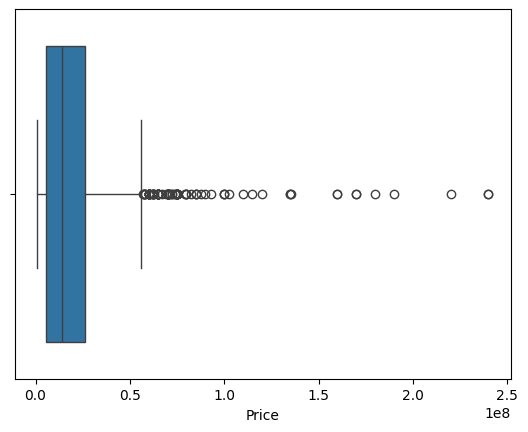

In [20]:
sns.boxplot(x=df['Price'])
plt.show()

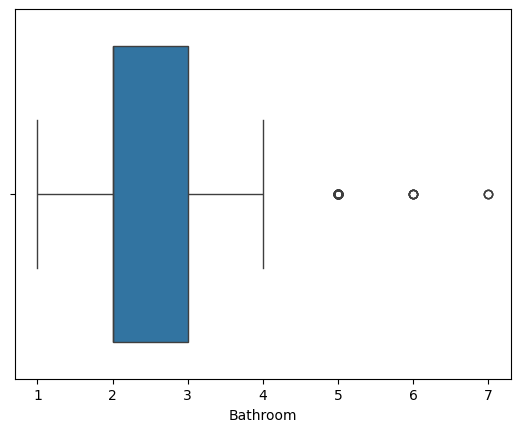

In [23]:
sns.boxplot(x=df['Bathroom'])
plt.show()

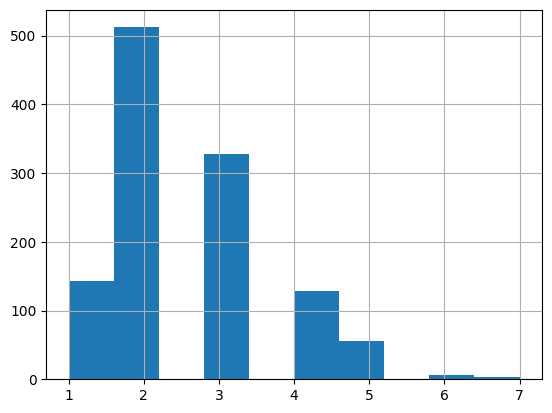

In [24]:
df['Bathroom'].hist()
plt.show()

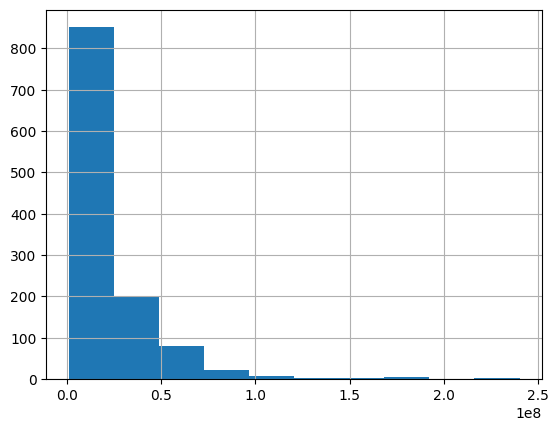

In [25]:
df['Price'].hist()
plt.show()

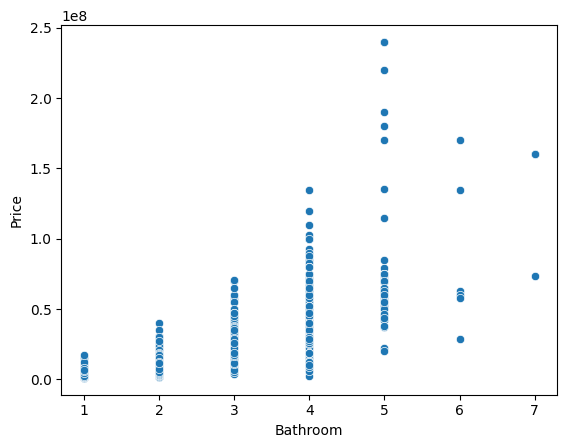

In [26]:
sns.scatterplot(x='Bathroom',y='Price',data=df)
plt.show()

In [27]:
df[['Bathroom','Price']].corr() 

,Bathroom,Price
Bathroom,1.000000,0.731684
Price,0.731684,1.000000


In [28]:
### feautre selection

x=df[['Bathroom']]
y=df['Price']



In [29]:
x

,Bathroom
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0
...,...
1254,5.0
1255,2.0
1256,3.0
1257,2.0


In [30]:
y

0        6500000
1        5000000
2       15500000
3        4200000
4        6200000
          ...   
1254    55000000
1255    12500000
1256    17500000
1257    11500000
1258    18500000
Name: Price, Length: 1176, dtype: int64

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
X_train

,Bathroom
43,2.0
540,2.0
816,3.0
625,1.0
140,2.0
...,...
1097,2.0
1178,2.0
1213,4.0
911,2.0


In [33]:
y_train

43       7800000
540     19000000
816      8500000
625      6500000
140     15000000
          ...   
1097    13500000
1178     6600000
1213    65000000
911      9000000
1209    85000000
Name: Price, Length: 940, dtype: int64

In [34]:
model=LinearRegression()

In [35]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred=model.predict(X_test)

In [37]:
y_pred

array([63255803.41608674, 11319749.94144807, 45943785.59120718,
       -5992267.88343149, 11319749.94144807, 11319749.94144807,
       63255803.41608674, 28631767.76632763, 11319749.94144807,
       45943785.59120718, 45943785.59120718, 11319749.94144807,
       28631767.76632763, 11319749.94144807, 11319749.94144807,
       -5992267.88343149, 11319749.94144807, 80567821.24096629,
       11319749.94144807, 11319749.94144807, 28631767.76632763,
       45943785.59120718, 11319749.94144807, 11319749.94144807,
       11319749.94144807, -5992267.88343149, 11319749.94144807,
       11319749.94144807, 28631767.76632763, 11319749.94144807,
       63255803.41608674, 28631767.76632763, 28631767.76632763,
       11319749.94144807, 63255803.41608674, -5992267.88343149,
       28631767.76632763, 63255803.41608674, -5992267.88343149,
       45943785.59120718, 11319749.94144807, 28631767.76632763,
       11319749.94144807, 28631767.76632763, -5992267.88343149,
       11319749.94144807, 28631767.76632

In [38]:
model.predict([[2]])

C:\Users\KIIT\OneDrive\Desktop\mlprojects\machine-learning-projects\ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11319749.94144807])

In [39]:
m=model.coef_[0]
b=model.intercept_

In [40]:
m,b

(np.float64(17312017.824879557), np.float64(-23304285.708311044))

In [41]:
price = m*3+b
print(price)

28631767.766327627


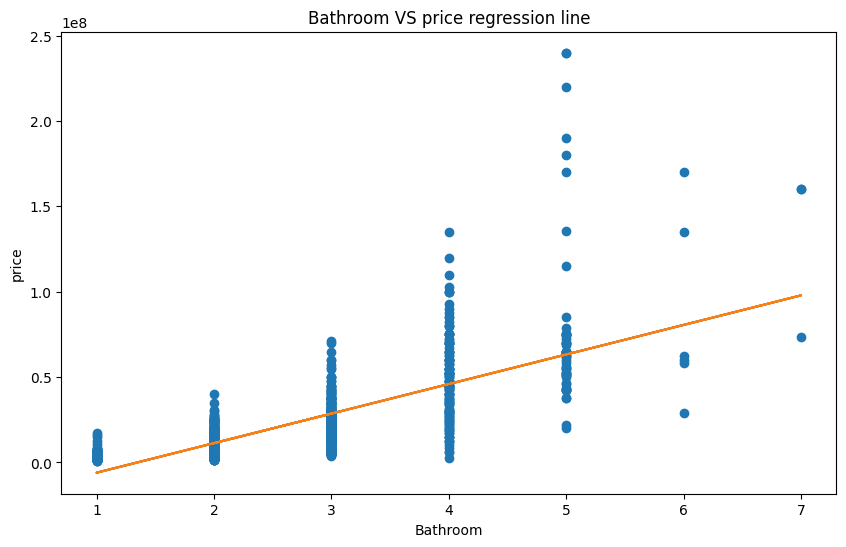

In [42]:

plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.plot(x,model.predict(x))
plt.plot(x,model.predict(x))
plt.xlabel("Bathroom")
plt.ylabel("price")
plt.title("Bathroom VS price regression line")
plt.show()

In [43]:
## mean absolute error


mae = mean_absolute_error(y_test,y_pred)

print(mae)

## mean squared error

mse = mean_squared_error(y_test,y_pred)

print(mse)

### rmse 

rmse = np.sqrt(mse)

print(rmse)

### r2 score

r2=r2_score(y_test,y_pred)

print(r2)

11789946.034581361
521276327116258.5
22831476.674018666
0.4347209229913709
